In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import json
import os
import re
import shutil
import sys

import cv2 as cv
from PIL import Image
import numpy as np

from opencsp import opencsp_settings
from contrib.common.lib.cv.spot_analysis.image_processor import *
from opencsp.common.lib.cv.CacheableImage import CacheableImage
from opencsp.common.lib.cv.SpotAnalysis import SpotAnalysis
from opencsp.common.lib.cv.annotations.HotspotAnnotation import HotspotAnnotation
from contrib.common.lib.cv.annotations.MomentsAnnotation import MomentsAnnotation
from contrib.common.lib.cv.annotations.SpotWidthAnnotation import SpotWidthAnnotation
from opencsp.common.lib.cv.spot_analysis.SpotAnalysisOperable import SpotAnalysisOperable
from opencsp.common.lib.cv.spot_analysis.image_processor import *
import opencsp.common.lib.render.Color as color
import opencsp.common.lib.render_control.RenderControlPointSeq as rcps
import opencsp.common.lib.tool.file_tools as ft
import opencsp.common.lib.tool.image_tools as it
import opencsp.common.lib.tool.log_tools as lt

# Local Variables
Set the paths below to match your system setup.

The "Collaborative Directory" in opencsp_settings is determined by your configuration file. See [Setup System Paths](https://opencsp.readthedocs.io/en/latest/contributing.html#setup-system-paths) in the Getting Started documentaiton for information on how to manage this setting.

In [ ]:
experiment_dir = os.path.join(opencsp_settings['opencsp_root_path']['collaborative_dir'], "Projects/_Directories/NSTTF_Optics_LookbackExEx/Experiments/2025-05-xx_DirectSunImages/1_Plan/saturation_test_shots/1xSunFilter_ManualFocus_VarExp")
input_dir = experiment_dir
intermediary_dir = os.path.join(experiment_dir, "intermediary")
output_dir = os.path.join(experiment_dir, "processed")

save_name_prefix = "saturation_test_shots_1xSunFilter_ManualFocus_VarExp"
experiment_name = "saturation_test_shots_1xSunFilter_ManualFocus_VarExp"

lt.info(input_dir)

[collaborative_dir]/Projects/_Directories/NSTTF_Optics_LookbackExEx/Experiments/2025-05-xx_DirectSunImages/1_Plan/saturation_test_shots/1xSunFilter_ManualFocus_VarExp


In [ ]:
# This code is here to support automatic testing of this notebook.
if "unittest_data_dir" in os.environ:
    experiment_dir = os.environ["unittest_data_dir"]
    input_dir = experiment_dir
    intermediary_dir = os.path.join(os.environ["unittest_out_dir"], "intermediary")
    output_dir = os.path.join(os.environ["unittest_out_dir"], "processed")

# Example Code

Everthing after this point should be universal for all setups.

### Locate Input Images

Next we need to locate the example input images. This includes all images in the input directory named above.

We also set up the intermediary directory and clear any previous results.

In [3]:
input_images = [ft.join(input_dir, fn) for fn in ft.files_in_directory_by_extension(input_dir, ["jpg"])["jpg"]]
print(f"Found {len(input_images)} input images in {input_dir}")

if ft.directory_exists(intermediary_dir):
    shutil.rmtree(intermediary_dir)
ft.create_directories_if_necessary(intermediary_dir)
ft.create_directories_if_necessary(output_dir)

Found 15 input images in [collaborative_dir]/Projects/_Directories/NSTTF_Optics_LookbackExEx/Experiments/2025-05-xx_DirectSunImages/1_Plan/saturation_test_shots/1xSunFilter_ManualFocus_VarExp


### Update Image Names

Copy the images and update their names to include the exposure time. This will help with our analysis later by making it easier for us to identify the exposure times from just the image name.

In [5]:
renamed_dir = ft.join(intermediary_dir, "renamed_images")
ft.create_directories_if_necessary(renamed_dir)
new_input_images: list[str] = []

for image_path_name_ext in input_images:
    image_path, image_name, image_ext = ft.path_components(image_path_name_ext)

    # get the exposure information from the image metadata
    try:
        exp_time = it.get_exif_value(image_path, image_name+image_ext, exif_val="EXIF:ExposureTime", parser=float)
    except Exception as ex:
        lt.error("Failed to retrieve the exposure information from the image metadata for image " + f"\"{image_path_name_ext}\". Continuing with unmodified image names.")
        new_input_images = None
        break
    exp_time_fraction = int(np.round(1.0 / exp_time))
    exp_time_str = f"1/{exp_time_fraction}" if exp_time < 1 else f"{exp_time:0.2f}"
    lt.info(f"{image_name}{image_ext}: exposure time = {exp_time_str}s", end="")

    # copy the image
    new_image_name = image_name+"_"+exp_time_str.replace("/","-")+"Exp"
    lt.info(f" => {new_image_name}{image_ext}")
    ft.copy_file(image_path_name_ext, renamed_dir, new_image_name+image_ext)

    # add to the list of new input image paths
    new_input_images.append(ft.join(renamed_dir, new_image_name+image_ext))

if new_input_images is not None:
    input_images = new_input_images

DSC_0139.JPG: exposure time = 1/2000s => DSC_0139_1-2000Exp.JPG


### Crop Input Images

The following crops the images to a smaller region around the centroid of the image. This has the benefit of limiting the size of the image that needs to be processed in subsequent code.

To determine the region to crop to, we:

1. convert the image to grayscale
2. find the minimum and maximum values in our set of images
3. subtract out the background noise, such as lens flare, camera static, or clouds in the sky
4. find the centroid of the image (aka the 0th moment)

Then we get the unmodified image and apply the crop to the determined region.

In [6]:
cropped_dir = ft.join(intermediary_dir, "cropped")

def centroid_pixel_locator(operable: SpotAnalysisOperable) -> tuple[int, int]:
    """Returns the x/y pixel location of the centroid center"""
    moments = filter(lambda a: isinstance(a, MomentsAnnotation), operable.annotations)
    mom_annotation: MomentsAnnotation = list(moments)[0]
    ret = mom_annotation.centroid.astuple()
    return (int(ret[0]), int(ret[1]))

def hotspot_pixel_locator(operable: SpotAnalysisOperable) -> tuple[int, int]:
    """Returns the x/y pixel location of the hotspot center"""
    hotspots = filter(lambda a: isinstance(a, HotspotAnnotation), operable.annotations)
    hs_annotation: HotspotAnnotation = list(hotspots)[0]
    ret = hs_annotation.origin.astuple()
    return (int(ret[0]), int(ret[1]))

def get_primary_prev_processor(operable: SpotAnalysisOperable, prev_processor: AbstractSpotAnalysisImageProcessor) -> np.ndarray:
    while operable.previous_operables[1] != prev_processor:
        operable = operable.previous_operables[0][0]
    operable = operable.previous_operables[0][0]
    return operable.primary_image.nparray

cropping_image_processors = {
    "EchoEcho": EchoImageProcessor(),
    "Original": ConvolutionImageProcessor(diameter=1),
    "Rgb2Gray": ColorConversionImageProcessor(),
    "PopStats": PopulationStatisticsImageProcessor(),
    "ConstSub": BackgroundColorSubtractionImageProcessor('constant', [50]),
    "Centroid": MomentsImageProcessor(
        include_visualization=True, centroid_style=rcps.default(color=color.cyan(), markersize=20)
    ),
    "GetOrigl": CustomSimpleImageProcessor(lambda o: get_primary_prev_processor(o, cropping_image_processors["Original"])),
    "CropCent": CroppingImageProcessor.by_center_and_size(centroid_pixel_locator, width=1400, height=1400),
}
cropping_image_processors_list = list(cropping_image_processors.values())
cropping_spot_analysis = SpotAnalysis(
    "Cropped", cropping_image_processors_list, save_dir=cropped_dir, save_overwrite=True
)
cropping_spot_analysis.set_primary_images(input_images)

cropped_images: list[str] = []
for result in cropping_spot_analysis:
    sa_notes = list(filter(lambda t_processor_notes: t_processor_notes[0] == "SpotAnalysis", result.image_processor_notes))
    saved_notes = list(filter(lambda note: "save_path" in note, sa_notes[0][1]))
    cropped_images.append(json.loads(saved_notes[0])["save_path"])

Processing image DSC_0139_1-2000Exp.JPG


[opencsp_dir]/common/lib/render/View3d.py:318: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  self.axis.arrow(


In CroppingImageProcessor(): cropping image from [0:6000,0:4000] to [2365:3765,852:2252]


### Preview the Cropped Images

The following shows the before and after results of the first cropped image. Change the value of `preview_index` to view the other images.

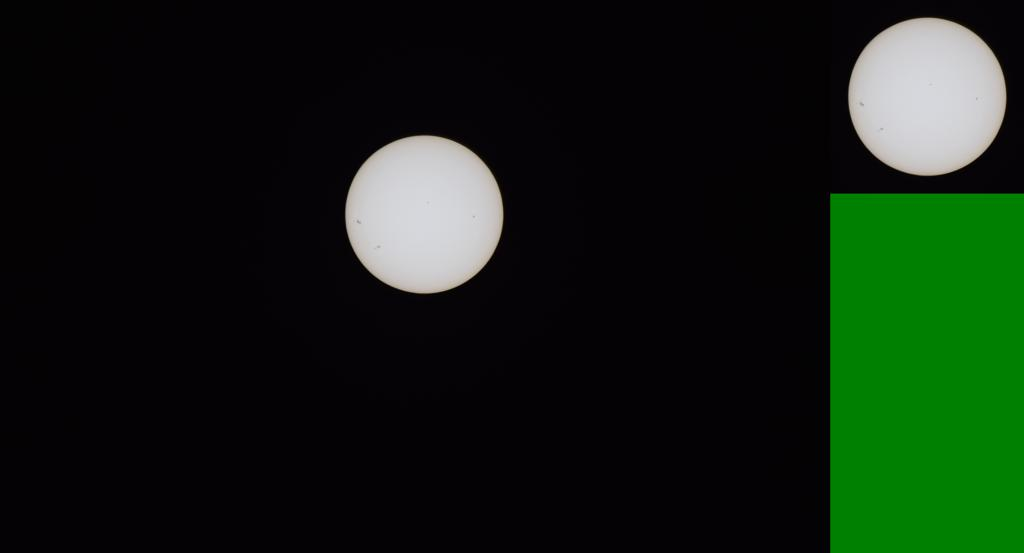

In [7]:
image_pairs = list(zip(input_images, cropped_images))

# show the before/after for the first image
preview_index = 0
from_img_pne, to_img_pne = image_pairs[preview_index]
from_img, to_img = CacheableImage.from_single_source(from_img_pne).to_image(), CacheableImage.from_single_source(to_img_pne).to_image()
w1, h1 = from_img.width, from_img.height
w2, h2 = to_img.width, to_img.height

comparison_img = Image.new(from_img.mode, (w1+w2, max(h1, h2)), color="green")
comparison_img.paste(from_img, (0, 0))
comparison_img.paste(to_img, (w1, 0))
comparison_img = comparison_img.resize((1024, int(1024 / comparison_img.width * comparison_img.height)))

comparison_img

### Locate and View the Cross Section

We use the SpotWidthImageProcessor to determine the spot width, and
several visualizer image processors to view the result.

The technique used to determine the spot size is to get the average
of all the half-maximum pixel locations, and the largest diameter of
opposite half-maximum pixels.

In [9]:
image_processors = {
    "EchoEcho": EchoImageProcessor(),
    "Original": ConvolutionImageProcessor(diameter=1),
    "Rgb2Gray": ColorConversionImageProcessor(),
    "Centroid": MomentsImageProcessor(
        include_visualization=True, centroid_style=rcps.default(color=color.cyan(), markersize=20)
    ),
    "SpotSize": SpotWidthImageProcessor(spot_width_technique="fwhm"),
    "VFalseCl": ViewFalseColorImageProcessor(),
    "VOverExp": ViewHighlightImageProcessor(black_highlight_color=(255, 0, 255), white_highlight_color=(100, 0, 100)),
    "VAnnotat": ViewAnnotationsImageProcessor(base_image_selector='visualization'),
    "VCrosSec": ViewCrossSectionImageProcessor(
        centroid_pixel_locator, single_plot=False, y_range=(0, 255)
    ),
    "ViewImg3d": View3dImageProcessor(max_resolution=(100, 100)),
}
_p = image_processors
processors_per_slide = [
    [(_p["Original"], "Rgb2Gray")],
    [(_p["Centroid"], "Centroid & Principle Axis"), (_p["VFalseCl"], "False Color"), _p["SpotSize"]],
    [_p["VOverExp"], _p["VAnnotat"]],
    [(_p["Original"], "Rgb2Gray"), _p["VCrosSec"], _p["ViewImg3d"]],
]
image_processors["PowerPnt"] = PowerpointImageProcessor(
    output_dir, save_name_prefix, overwrite=True, processors_per_slide=processors_per_slide
)

image_processors_list = list(image_processors.values())

spot_analysis = SpotAnalysis(
    experiment_name, image_processors_list, save_dir=output_dir, save_overwrite=True
)
spot_analysis.set_primary_images(cropped_images)

for result in spot_analysis:
    pass

import matplotlib.pyplot as plt
plt.close('all')

lt.info(f"Saved powerpoint to\n{image_processors['PowerPnt'].dest_path_name_ext}")

Processing image DSC_0139_1-2000Exp_Cropped.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/1_13.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/1_14.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/1_15.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/1_16.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/1_17.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/1_18.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/1_19.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/2_0.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/2_1.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/2_2.png
saving image to [scratch_dir]/tmp/PowerpointImage/images/tmp/2_3.png
In PowerpointSlide.render()
In PowerpointSlide.render()
In PowerpointSlide.render()
In PowerpointSlide.render()
In SpotAnalaysis._save_image(): saving over existing primary image file [c

0

### Preview the Result

Spot width is 1142 pixels


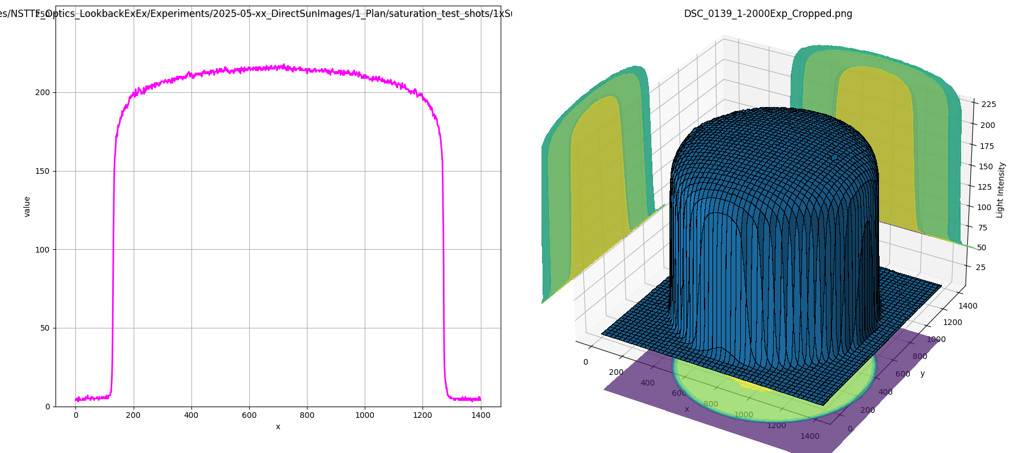

In [11]:
spot_width_annotation: SpotWidthAnnotation = result.get_fiducials_by_type(SpotWidthAnnotation)[0]
lt.info(f"Spot width is {int(spot_width_annotation.width)} pixels")

vis_img1 = list(result.visualization_images.values())[-2][1].to_image()
vis_img2 = list(result.visualization_images.values())[-1][0].to_image()
w1, h1 = vis_img1.width, vis_img1.height
w2, h2 = vis_img2.width, vis_img2.height

combined_img = Image.new(vis_img1.mode, (w1+w2, max(h1, h2)), color="green")
combined_img.paste(vis_img1, (0, 0))
combined_img.paste(vis_img2, (w1, 0))
combined_img = combined_img.resize((1024, int(1024 / combined_img.width * combined_img.height)))

combined_img